In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Este dataset se encuentra en la carpeta `data/` del proyecto.

- **Muestra (trackeada en git):** `data/creditcard_sample.csv` (2050 filas)
- **Dataset completo:** ejecutar `python scripts/download_data.py` para descargarlo
  desde [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)


## 1.- Analisis exploratorio

In [2]:
df = pd.read_csv('../data/creditcard_sample.csv')


In [3]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,138900.0,1.915291,-1.273465,-1.640527,-1.034564,-0.394319,-0.401375,-0.327757,-0.099092,-0.591106,...,0.040646,-0.376352,0.155124,0.309713,-0.263552,-0.469310,-0.078511,-0.039547,162.80,0
1,81007.0,-2.252045,1.237341,-0.378933,1.043935,-1.881279,-0.185669,1.443861,0.434369,-0.441784,...,-0.033593,0.441324,0.167816,0.421270,0.014332,-0.291088,0.612198,-0.091700,297.15,0
2,66856.0,-0.385786,-0.775209,2.557841,-1.626725,-1.772785,-0.483265,-0.913807,0.121463,-1.613919,...,-0.109415,0.110904,0.036711,0.689073,-0.329436,-0.261468,0.160090,0.137700,32.00,0
3,52911.0,1.301979,-0.215752,-1.615234,-1.052613,2.142779,2.977535,-0.276264,0.661874,-0.143607,...,-0.116204,-0.537789,-0.095282,1.076181,0.576696,1.020670,-0.105105,-0.004901,38.50,0
4,134354.0,0.160173,1.015455,-0.500712,-0.589341,0.984274,-0.714191,0.971068,-0.087963,-0.005521,...,-0.356679,-0.889700,0.077037,0.364277,-0.398066,0.125973,0.220028,0.081899,5.94,0


In [ ]:
df.shape

(2050, 31)

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    2050 non-null   float64
 1   V1      2050 non-null   float64
 2   V2      2050 non-null   float64
 3   V3      2050 non-null   float64
 4   V4      2050 non-null   float64
 5   V5      2050 non-null   float64
 6   V6      2050 non-null   float64
 7   V7      2050 non-null   float64
 8   V8      2050 non-null   float64
 9   V9      2050 non-null   float64
 10  V10     2050 non-null   float64
 11  V11     2050 non-null   float64
 12  V12     2050 non-null   float64
 13  V13     2050 non-null   float64
 14  V14     2050 non-null   float64
 15  V15     2050 non-null   float64
 16  V16     2050 non-null   float64
 17  V17     2050 non-null   float64
 18  V18     2050 non-null   float64
 19  V19     2050 non-null   float64
 20  V20     2050 non-null   float64
 21  V21     2050 non-null   float64
 22  V22     205

In [6]:
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,2050.000000,2050.000000,2050.000000,2050.000000,2050.000000,2050.000000,2050.000000,2050.000000,2050.000000,2050.000000,...,2050.000000,2050.000000,2050.000000,2050.000000,2050.000000,2050.000000,2050.000000,2050.000000,2050.000000,2050.000000
mean,94287.758049,-0.199512,0.052813,-0.240673,0.091616,-0.040654,-0.061831,-0.168611,0.064707,-0.047335,...,0.037902,-0.010487,-0.013525,-0.004214,-0.003055,-0.000154,0.010007,0.009664,86.771985,0.024390
std,47811.576413,2.636362,2.024644,2.392516,1.596035,1.889370,1.423739,1.854597,1.749551,1.226549,...,0.972374,0.747535,0.541560,0.618371,0.534794,0.484334,0.445267,0.447607,216.407670,0.154295
min,56.000000,-29.876366,-29.336007,-30.558697,-4.519509,-21.665654,-17.282140,-21.116854,-37.353443,-8.507059,...,-14.045185,-8.887017,-9.002474,-2.836627,-2.561728,-1.237618,-6.592504,-4.587719,0.000000,0.000000
25%,52698.250000,-0.986167,-0.602131,-0.993274,-0.829373,-0.685570,-0.784924,-0.605843,-0.221796,-0.670825,...,-0.232697,-0.557642,-0.168440,-0.354737,-0.332370,-0.335650,-0.069329,-0.051010,5.000000,0.000000
50%,84920.000000,-0.062779,0.072947,0.096964,0.019286,-0.014039,-0.282410,0.030420,0.026694,-0.068855,...,-0.022799,-0.002403,-0.018046,0.035484,0.032090,-0.050519,0.000992,0.012320,21.780000,0.000000
75%,138661.750000,1.291249,0.838408,0.959231,0.795606,0.658446,0.380576,0.574694,0.348854,0.603121,...,0.203672,0.518425,0.143294,0.442803,0.337683,0.236192,0.096124,0.083305,79.767500,0.000000
max,172619.000000,2.370007,16.434525,3.770236,11.786180,28.516513,6.220135,7.705953,19.587773,6.474148,...,27.202839,3.668979,8.073049,2.971582,2.156042,2.859167,4.359143,15.373170,4000.000000,1.000000


In [7]:
df.isna().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.isin([np.inf, -np.inf]).sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### A.- Analisis univariado

In [9]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)


In [10]:
df_num = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
        'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
        'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


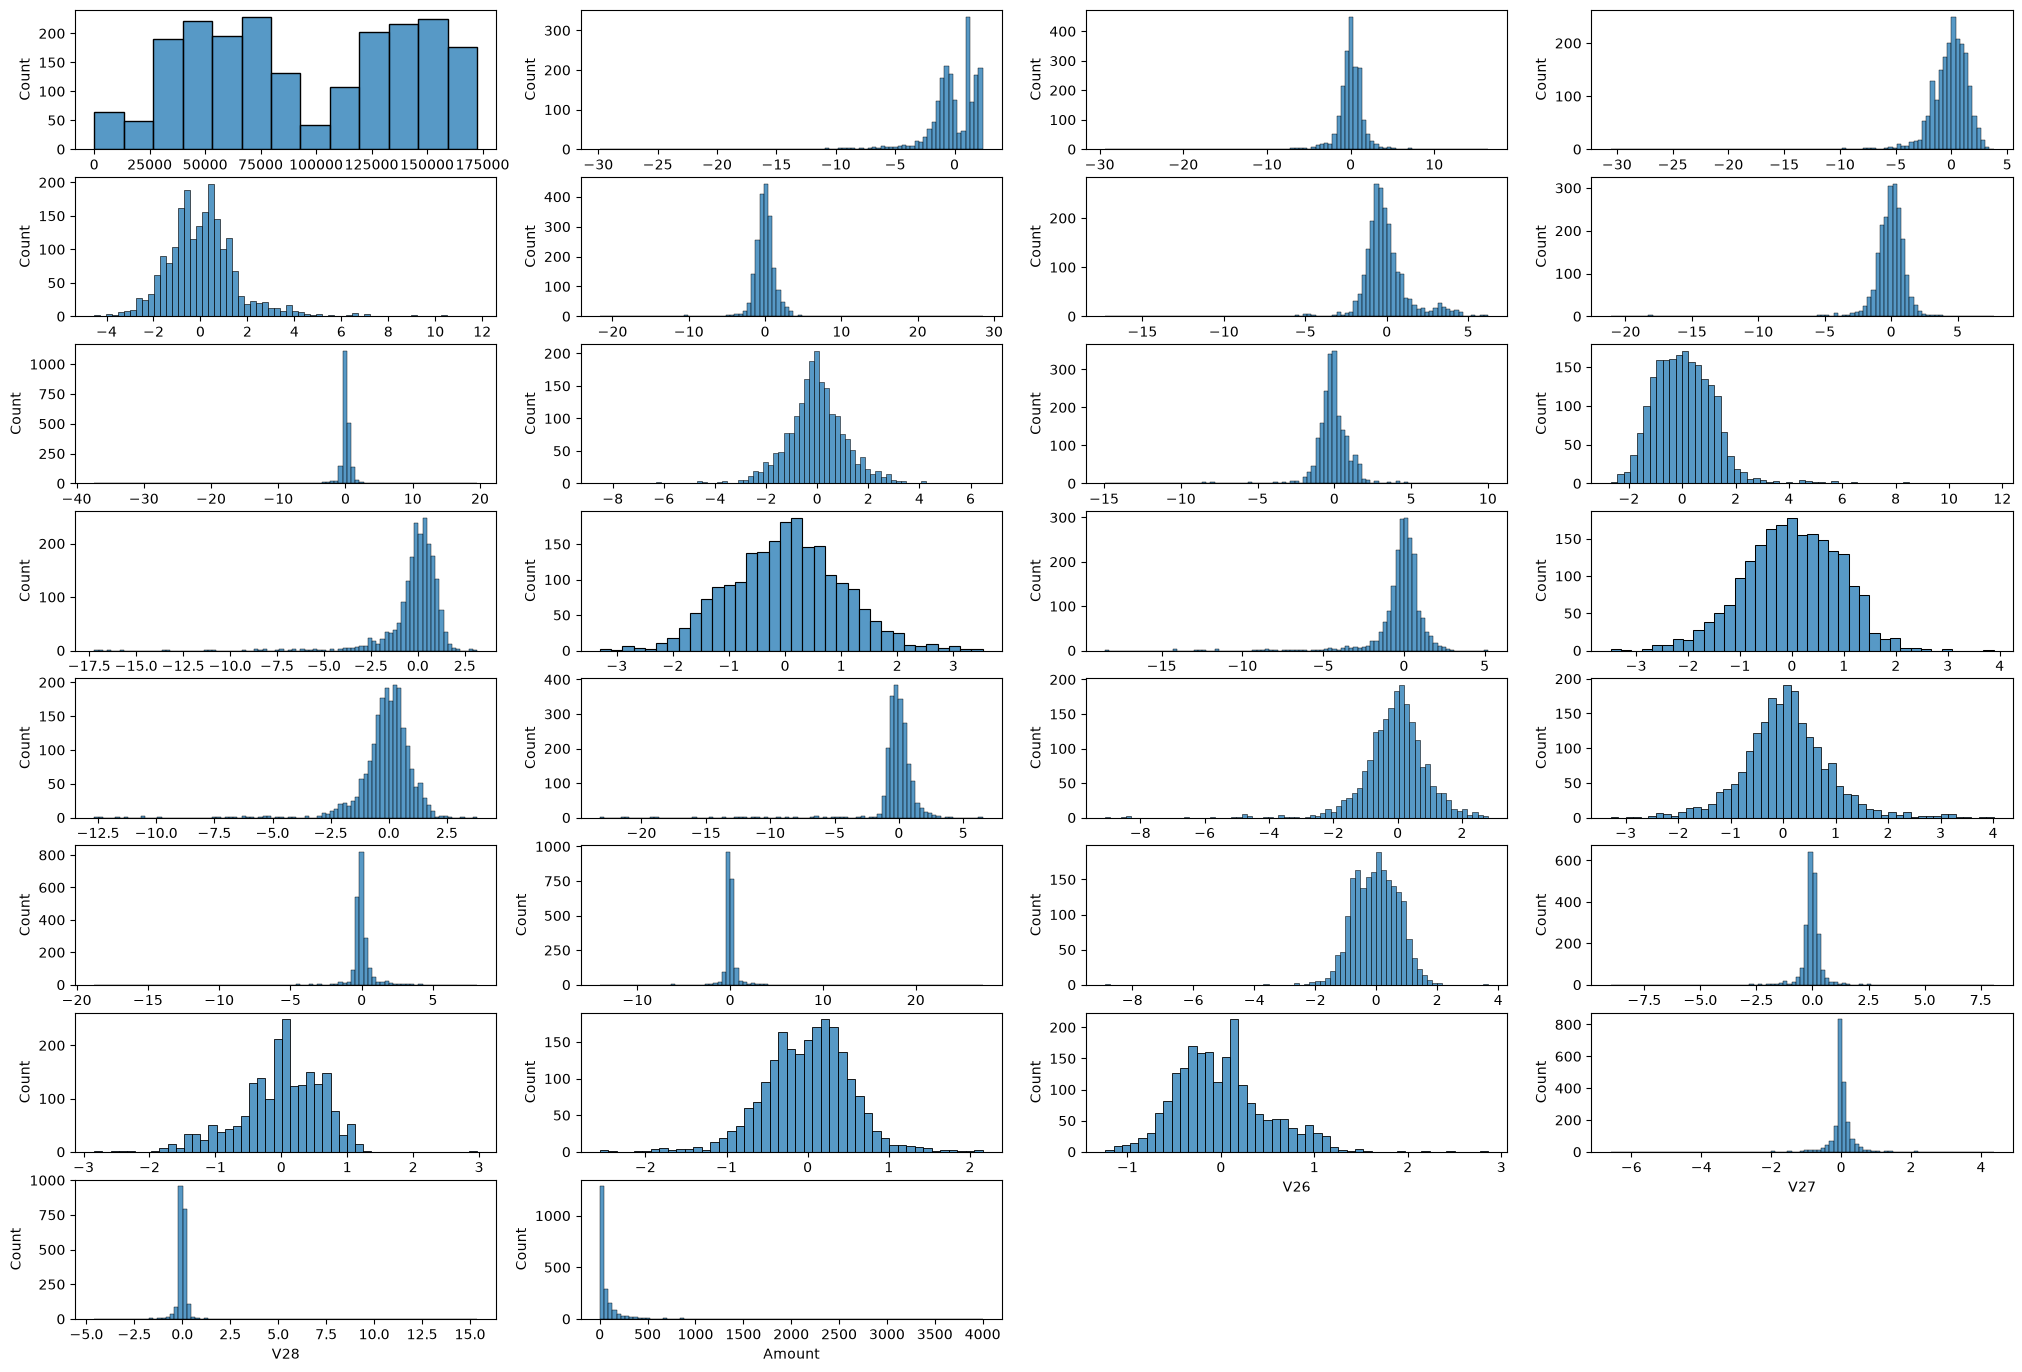

In [11]:
plt.figure(figsize=(25, 17))

for i, name in enumerate(df_num, start=1):
    plt.subplot(8, 4, i)
    sns.histplot(data=df, x=name)


<Axes: xlabel='Class', ylabel='count'>

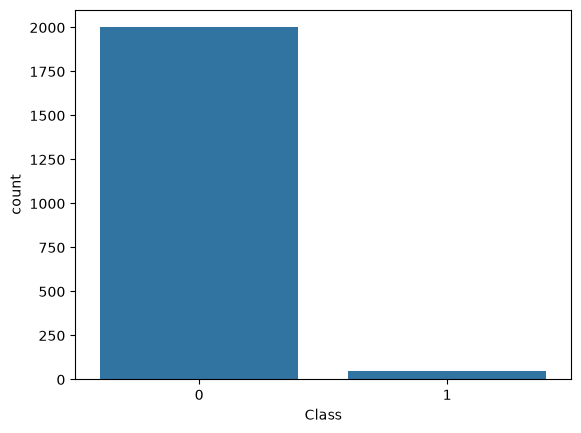

In [12]:
sns.countplot(data=df, x='Class')


### B.- Analisis bivariado

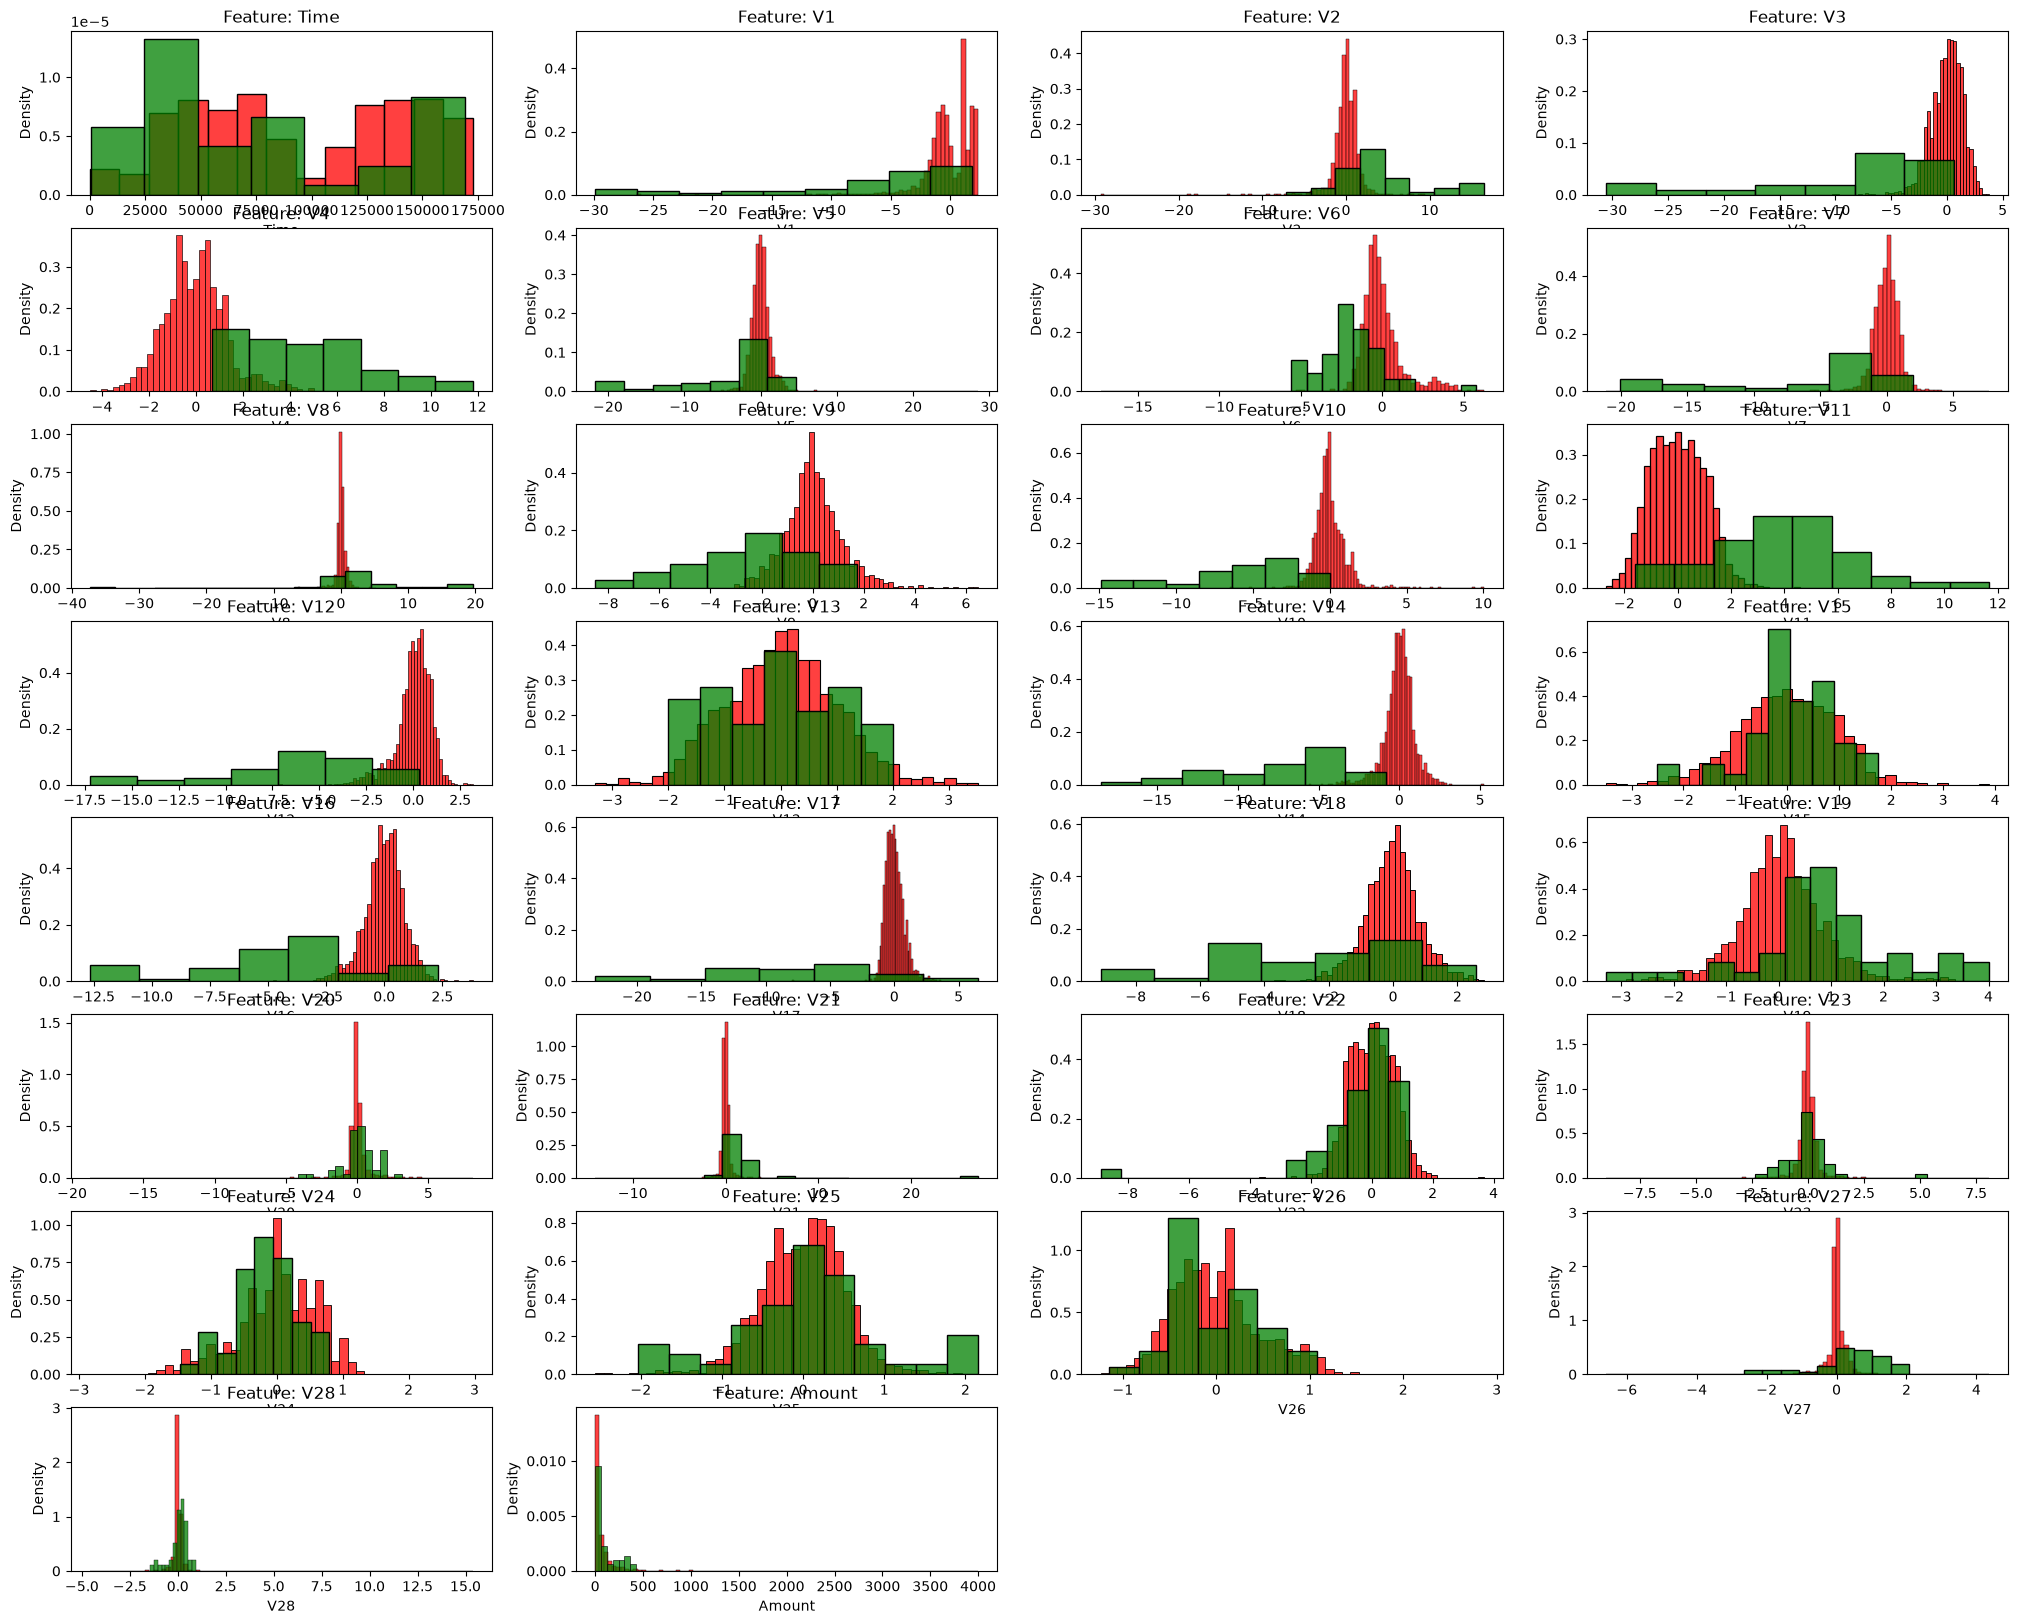

In [13]:
plt.figure(figsize=(25, 20))

for i, name in enumerate(df_num, start=1):
    plt.subplot(8, 4, i)
    sns.histplot(data=df[df['Class']==0], x=name, color='red', stat="density", )
    sns.histplot(data=df[df['Class']==1], x=name, color='green', stat="density", )
    plt.title(f"Feature: {name}")


### Conclusiones

* Parece que los valores mas importantes para este problema podrian ser V18, V6, V15
* Se aplico pca al dataset por lo que no hara falta eliminar los valores atipicos o preprocesarlo, o por lo menos no es lo optimo


### Preprocesamiento recomendado

1. **Train-test split** — 70/30.
2. **No necesita escalado** — ya viene PCA.
3. **Manejar desbalanceo** — solo 0.17% fraudes, considerar sampling.